In [21]:
import json
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import warnings
import sqlite3

warnings.filterwarnings('ignore')

# ==================== CONFIGURATION ====================

# Timestamps (Update these based on your runs)
TS_SCALING = "20260107_211932_SCALING_SNAPSHOT"
TS_DISTRIBUTION = "20260107_210341_DISTRIBUTION_SNAPSHOT"
TS_NSYS = "20260107_214611_SNAPSHOT"
TS_NCU = "20260108_025939_SNAPSHOT"

# Base Paths
BENCHMARK_RESULTS_DIR = Path("benchmark/results")
PROFILING_RESULTS_DIR = Path("profiling/results")
NSYS_DIR = PROFILING_RESULTS_DIR / "nsys" / TS_NSYS
NCU_DIR = PROFILING_RESULTS_DIR / "ncu" / TS_NCU

# ==================== IMPROVED STYLING ====================

# Dimensions for Two-Column Paper
SINGLE_COL_WIDTH = 3.5  # inches
DOUBLE_COL_WIDTH = 7.2  # inches
GOLDEN_RATIO = 1.618

# User Adjustments
CHART_HEIGHT_SCALE = 1.0  # Increase to make charts taller
X_LABEL_ROTATION = 15     # Max rotation in degrees

# Publication-quality styling
sns.set_style("whitegrid", {
    'grid.linestyle': '--',
    'grid.alpha': 0.3,
    'axes.edgecolor': '.2',
    'axes.linewidth': 0.8
})

plt.rcParams.update({
    'font.size': 8,
    'axes.labelsize': 8,
    'axes.titlesize': 9,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'legend.fontsize': 7,
    'legend.title_fontsize': 8,
    'figure.titlesize': 10,
    'font.family': 'sans-serif',
    'axes.linewidth': 0.8,
    'grid.linewidth': 0.5,
    'lines.linewidth': 1.5,
    'lines.markersize': 5,
    'patch.linewidth': 0.6,
    'figure.dpi': 300,
    'savefig.dpi': 300
})

# ==================== COLOR PALETTE ====================

# Professional, colorblind-friendly palette
IMPL_COLORS = {
    'cpu': '#D32F2F',                    # Red
    'optimized-cuda': '#1976D2',         # Blue
    'sparse-cuda': '#7B1FA2',            # Purple
    
    # Naive MPI
    'naive-cuda-mpi:linear': '#FBC02D',  # Yellow
    'naive-cuda-mpi:louvain': '#757575', # Gray
    'naive-cuda-mpi:red-blue': '#00ACC1', # Cyan
    
    # Optimized MPI
    'optimized-cuda-mpi:linear': '#388E3C',   # Green
    'optimized-cuda-mpi:louvain': '#F57C00',  # Orange
    'optimized-cuda-mpi:red-blue': '#5D4037', # Brown
}

# Component colors
COMPONENT_COLORS = {
    'CUDA Kernel': '#1976D2',
    'CUDA Memory': '#7B1FA2',
    'MPI': '#D32F2F',
    'CPU': '#F57C00'  # Added CPU color
}

# Functionality colors
FUNC_COLORS = {
    'Evaluation': '#1976D2',
    'Propagation': '#D32F2F',
    'MPI Communication': '#388E3C',
    'Maintenance': '#757575',
    'Other': '#FBC02D'
}

# Memory hierarchy colors (fast to slow)
MEM_COLORS = {
    'L1 Cache': '#388E3C',      # Green (fast)
    'L2 Cache': '#F57C00',      # Orange
    'Global Memory': '#D32F2F'  # Red (slow)
}

print("✓ Configuration loaded")

✓ Configuration loaded


In [22]:
# ==================== DATA LOADING UTILITIES ====================

def load_benchmark_data(timestamp):
    """Parse Google Benchmark JSON output."""
    json_path = BENCHMARK_RESULTS_DIR / timestamp / "data.json"
    if not json_path.exists():
        print(f"⚠ Benchmark file not found: {json_path}")
        return pd.DataFrame()
    
    with open(json_path, 'r') as f:
        data = json.load(f)
        
    records = []
    for bench in data['benchmarks']:
        name = bench['name']
        parts = name.split('/')
        
        if len(parts) >= 3:
            impl = parts[0]
            dist = parts[1]
            try:
                size = int(parts[2])
            except ValueError:
                size = 0
            
            records.append({
                'Implementation': impl,
                'Distribution': dist,
                'Size': size,
                'RealTime': bench['real_time'],
                'TimeUnit': bench.get('time_unit', 'ns'),
                'RunType': bench.get('run_type', 'iteration')
            })
            
    df = pd.DataFrame(records)
    
    if not df.empty:
        def to_ms(row):
            t, u = row['RealTime'], row['TimeUnit']
            if u == 'ns': return t / 1e6
            if u == 'us': return t / 1e3
            if u == 'ms': return t
            if u == 's': return t * 1e3
            return t
        
        df['TimeMS'] = df.apply(to_ms, axis=1)
        
    return df


def load_nsys_summary(impl_name, rank=0):
    """Load Nsys profiling summary including CPU time from SQLite."""
    base = NSYS_DIR / impl_name
    
    metrics = {'CUDA Kernel': 0, 'CUDA Memory': 0, 'MPI': 0, 'CPU': 0}
    
    # GPU metrics
    gpu_files = list(base.glob(f"*rank{rank}*stats_cuda_api_gpu_sum.csv"))
    if not gpu_files:
        gpu_files = list(base.glob("*stats_cuda_api_gpu_sum.csv"))
    
    if gpu_files:
        try:
            df_gpu = pd.read_csv(gpu_files[0])
            metrics['CUDA Kernel'] = df_gpu[df_gpu['Category'] == 'CUDA_KERNEL']['Total Time (ns)'].sum()
            metrics['CUDA Memory'] = df_gpu[df_gpu['Category'] == 'MEMORY_OPER']['Total Time (ns)'].sum()
        except Exception:
            pass
    
    # MPI metrics
    mpi_files = list(base.glob(f"*rank{rank}*stats_mpi_event_sum.csv"))
    if not mpi_files:
        mpi_files = list(base.glob("*stats_mpi_event_sum.csv"))
    
    if mpi_files:
        try:
            df_mpi = pd.read_csv(mpi_files[0])
            metrics['MPI'] = df_mpi['Total Time (ns)'].sum()
        except Exception:
            pass

    # CPU metrics (Wall Time - GPU - MPI) using SQLite
    sqlite_files = list(base.glob(f"*rank{rank}*.sqlite"))
    if not sqlite_files:
         # Fallback to verify if any sqlite exists in directory
         sqlite_files = list(base.glob("*.sqlite"))

    if sqlite_files:
        try:
            conn = sqlite3.connect(sqlite_files[0])
            cursor = conn.cursor()
            
            # Get Wall Time
            # Use SCHED_EVENTS to approximate application wall time
            cursor.execute("SELECT MIN(start), MAX(start) FROM SCHED_EVENTS")
            row = cursor.fetchone()
            
            if row and row[0] is not None and row[1] is not None:
                min_start, max_start = row
                wall_time_ns = max_start - min_start
                
                # Calculate CPU
                # CPU = Wall - (GPU + MPI)
                gpu_total = metrics['CUDA Kernel'] + metrics['CUDA Memory']
                mpi_total = metrics['MPI']
                
                # Assuming serialized behavior for breakdown
                metrics['CPU'] = max(0, wall_time_ns - gpu_total - mpi_total)
            
            conn.close()
        except Exception as e:
            print(f"Error querying sqlite for {impl_name}: {e}")
    
    return metrics


print("✓ Data loading utilities ready")


✓ Data loading utilities ready


---
## Figure 1: Scaling Performance (Speedup vs CPU)

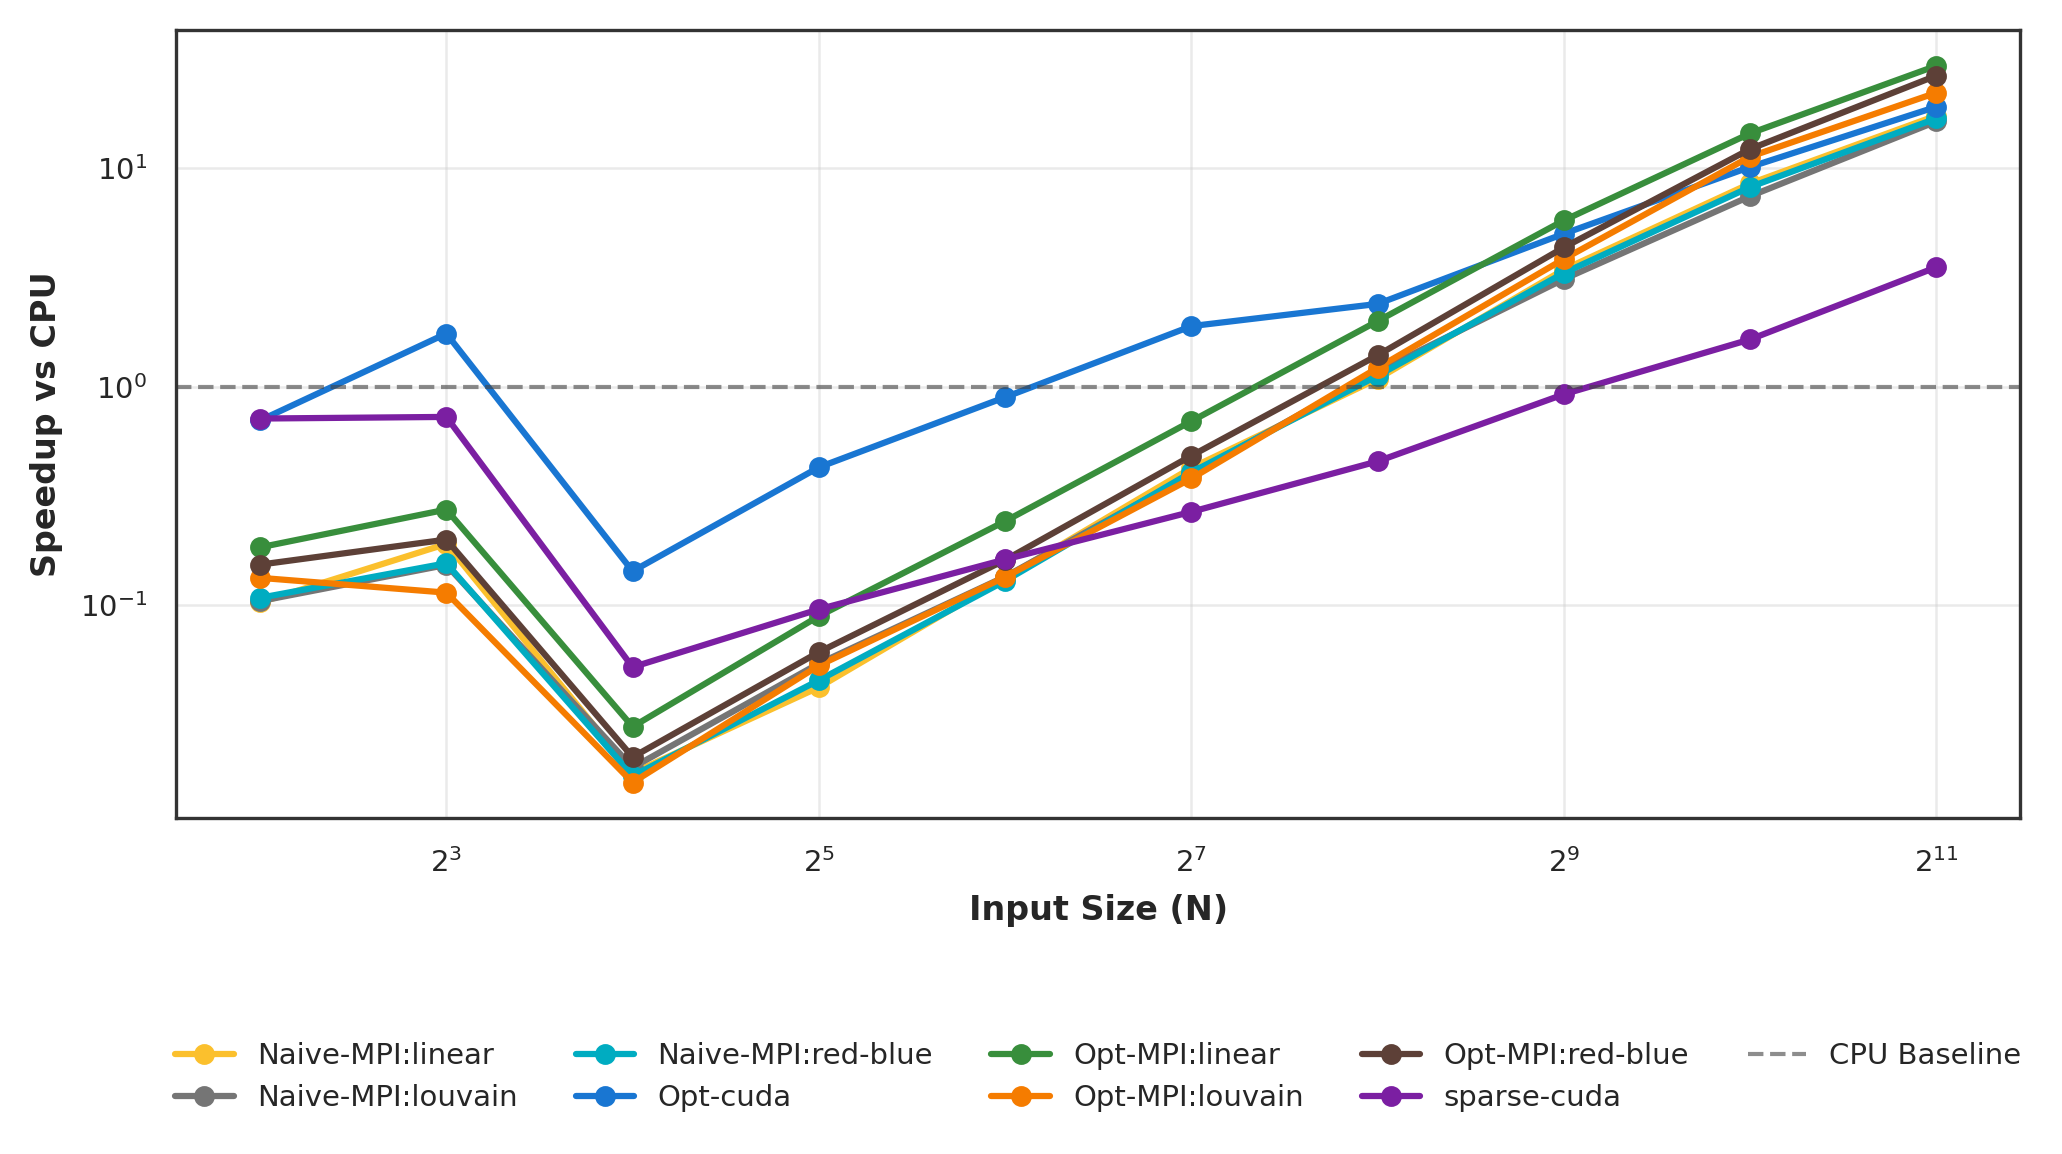

In [23]:
df_scale = load_benchmark_data(TS_SCALING)

if not df_scale.empty:
    target_dist = 'reverse-sorted'
    subset = df_scale[
        (df_scale['Distribution'] == target_dist) & 
        (df_scale['RunType'] == 'iteration')
    ].copy()
    
    if subset.empty:
        print(f"⚠ No data for '{target_dist}', using all available")
        subset = df_scale[df_scale['RunType'] == 'iteration'].copy()
        target_dist = 'all'
        
    # Calculate speedup vs CPU
    cpu_times = subset[subset['Implementation'] == 'cpu'].groupby('Size')['TimeMS'].mean()
    
    if not cpu_times.empty:
        subset['CPU_Time'] = subset['Size'].map(cpu_times)
        subset['Speedup'] = subset['CPU_Time'] / subset['TimeMS']
        
        # Aggregate by mean
        plot_data = subset.groupby(['Implementation', 'Size'])['Speedup'].mean().reset_index()
        
        # Save to CSV
        plot_data.to_csv('paper_figs/fig1_scaling.csv', index=False)
        
        # Create figure - DOUBLE COLUMN
        fig, ax = plt.subplots(figsize=(DOUBLE_COL_WIDTH, 4 * CHART_HEIGHT_SCALE))
        
        # Plot each implementation
        # Filter to keep plot readable if too many lines
        priority_impls = ['optimized-cuda', 'sparse-cuda', 'optimized-cuda-mpi:louvain', 'naive-cuda-mpi:linear']
        
        for impl in plot_data['Implementation'].unique():
            if impl == 'cpu': continue
            
            # Simple filtering logic if we have too many, or just plot all
            # For now, plot all but maybe style priority ones differently? 
            # Or just plot all as scaling usually needs comparison.
            
            impl_data = plot_data[plot_data['Implementation'] == impl]
            color = IMPL_COLORS.get(impl, '#333333')
            
            # Simplify label
            label = impl.replace('cuda-mpi', 'MPI').replace('optimized', 'Opt').replace('naive', 'Naive')
            
            ax.plot(impl_data['Size'], impl_data['Speedup'], 
                   marker='o', color=color, label=label, linewidth=1.5, markersize=4)
        
        # Baseline
        ax.axhline(1, color='#424242', linestyle='--', alpha=0.6, linewidth=1.0, 
                  label='CPU Baseline')
        
        # Styling
        ax.set_xscale('log', base=2)
        ax.set_yscale('log')
        ax.set_xlabel('Input Size (N)', fontweight='bold')
        ax.set_ylabel('Speedup vs CPU', fontweight='bold')
        # ax.set_title(f'Scaling Performance ({target_dist})', 
        #             pad=10, fontweight='bold')
        
        ax.grid(True, which='major', alpha=0.4, linestyle='-', linewidth=0.6)
        
        # Legend inside or below? Below for 2-col usually better to save vertical space?
        # Or right side. Let's put it below.
        ax.legend(bbox_to_anchor=(0.5, -0.25), loc='upper center', frameon=False,
                 ncol=5)
        
        plt.tight_layout()
        plt.savefig('paper_figs/fig1_scaling.png', bbox_inches='tight', dpi=300)
        plt.show()
    else:
        print("⚠ No CPU baseline found")
else:
    print("⚠ No scaling data available")

---
## Figure 2: Distribution Stability Analysis

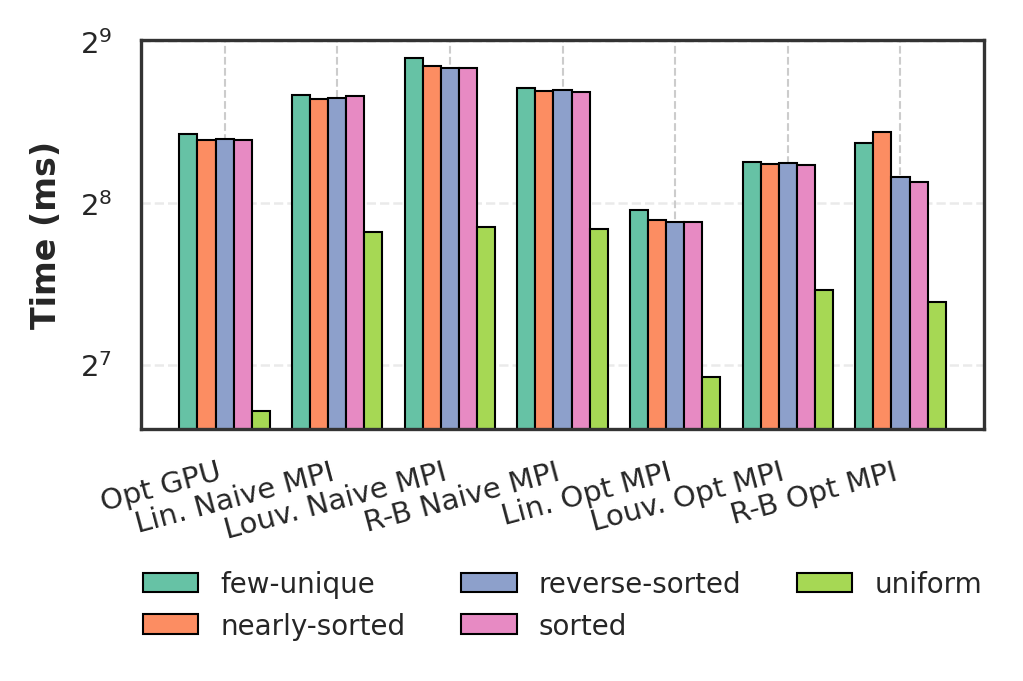

In [24]:
df_dist = load_benchmark_data(TS_DISTRIBUTION)

if not df_dist.empty:
    # Use max size (assuming it corresponds to the highest input size of scaling benchmark available in distribution runs)
    target_size = df_dist['Size'].max()
    
    if pd.notna(target_size):
        subset = df_dist[
            (df_dist['Size'] == target_size) &
            (df_dist['RunType'] == 'iteration')
        ].copy()
        
        # Filter implementations to reduce clutter for SINGLE COLUMN
        # We keep CPU, Opt-CUDA, Sparse, and the Best MPI (Opt-Louvain) and Baseline MPI (Naive-Linear)
        keep_impls = [
            'optimized-cuda', 
            'naive-cuda-mpi:linear',
            'naive-cuda-mpi:louvain',
            'naive-cuda-mpi:red-blue',
            'optimized-cuda-mpi:linear',
            'optimized-cuda-mpi:louvain',
            'optimized-cuda-mpi:red-blue'
        ]
        subset = subset[subset['Implementation'].isin(keep_impls)]
        
        # Shorten implementation names for labels
        name_map = {
            'optimized-cuda': 'Opt GPU',
            'naive-cuda-mpi:linear': 'Lin. Naive MPI',
            'naive-cuda-mpi:louvain': 'Louv. Naive MPI',
            'naive-cuda-mpi:red-blue': 'R-B Naive MPI',
            'optimized-cuda-mpi:linear': 'Lin. Opt MPI',
            'optimized-cuda-mpi:louvain': 'Louv. Opt MPI',
            'optimized-cuda-mpi:red-blue': 'R-B Opt MPI'
        }
        
        # Aggregate to mean
        plot_data = subset.groupby(['Implementation', 'Distribution'])['TimeMS'].mean().reset_index()
        
        # Save to CSV
        plot_data.to_csv('paper_figs/fig2_distribution.csv', index=False)

        # Create figure - SINGLE COLUMN
        fig, ax = plt.subplots(figsize=(SINGLE_COL_WIDTH, 2.5 * CHART_HEIGHT_SCALE))
        
        # Get unique values
        distributions = sorted(plot_data['Distribution'].unique())
        implementations = [i for i in keep_impls if i in plot_data['Implementation'].unique()] # Preserve order
        
        x = np.arange(len(implementations))
        width = 0.8 / len(distributions)
        
        # Use a nice color palette for distributions
        dist_colors = sns.color_palette("Set2", len(distributions))
        
        # Plot grouped bars
        for i, dist in enumerate(distributions):
            dist_data = plot_data[plot_data['Distribution'] == dist]
            values = [dist_data[dist_data['Implementation'] == impl]['TimeMS'].values[0] 
                     if impl in dist_data['Implementation'].values else 0 
                     for impl in implementations]
            
            offset = (i - len(distributions)/2 + 0.5) * width
            ax.bar(x + offset, values, width, label=dist, 
                  color=dist_colors[i], edgecolor='black', linewidth=0.5)
        
        ax.set_ylabel('Time (ms)', fontweight='bold')
        # ax.set_title(f'Performance at Max Scale (N={int(target_size)})', pad=10, fontweight='bold')
        
        ax.set_xticks(x)
        ax.set_xticklabels([name_map.get(i, i) for i in implementations], 
                          rotation=X_LABEL_ROTATION, ha='right')
        
        ax.grid(axis='y', alpha=0.4, linewidth=0.6)
        ax.set_yscale('log', base=2) # Log scale often helps if CPU is included
        
        # Legend
        ax.legend(title=None, bbox_to_anchor=(0.5, -0.3), 
                 loc='upper center', frameon=False, ncol=3,
                 fontsize='small')
        
        plt.tight_layout()
        plt.savefig('paper_figs/fig2_distribution.png', bbox_inches='tight', dpi=300)
        plt.show()
    else:
        print("⚠ Could not determine size")
else:
    print("⚠ No distribution data available")

---
## Figure 3: Execution Time Breakdown (Profiling)

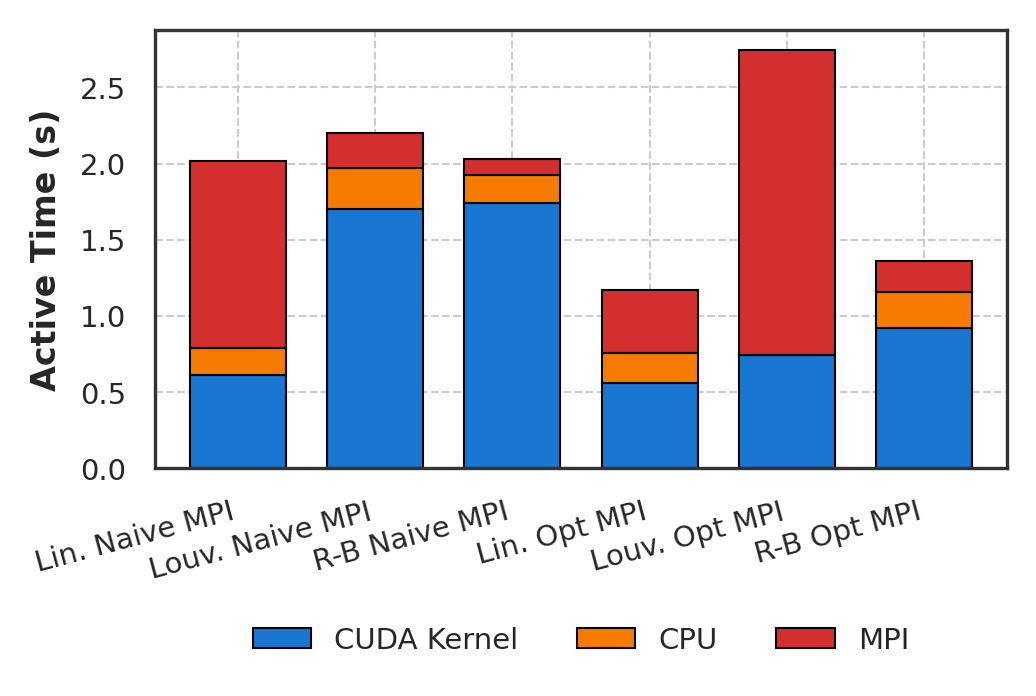

In [25]:
nsys_impls = [
    'naive-cuda-mpi-linear',
    'naive-cuda-mpi-louvain',
    'naive-cuda-mpi-red-blue',
    'optimized-cuda-mpi-linear',
    'optimized-cuda-mpi-louvain',
    'optimized-cuda-mpi-red-blue'
]
# Removed red-blue and variants to fit column

breakdown_data = []

for impl in nsys_impls:
    stats = load_nsys_summary(impl, rank=0)
    # Include CPU in stats check
    if stats['CUDA Kernel'] > 0 or stats['MPI'] > 0 or stats.get('CPU', 0) > 0:
        breakdown_data.append({
            'Implementation': impl,
            'CUDA Kernel': stats['CUDA Kernel'] / 1e9,
            'CUDA Memory': stats['CUDA Memory'] / 1e9,
            'MPI': stats['MPI'] / 1e9,
            'CPU': stats.get('CPU', 0) / 1e9
        })

if breakdown_data:
    df_nsys = pd.DataFrame(breakdown_data)
    df_nsys.set_index('Implementation', inplace=True)
    
    # Shorten names
    short_names = {
            'naive-cuda-mpi-linear': 'Lin. Naive MPI',
            'naive-cuda-mpi-louvain': 'Louv. Naive MPI',
            'naive-cuda-mpi-red-blue': 'R-B Naive MPI',
            'optimized-cuda-mpi-linear': 'Lin. Opt MPI',
            'optimized-cuda-mpi-louvain': 'Louv. Opt MPI',
            'optimized-cuda-mpi-red-blue': 'R-B Opt MPI'
    }
    df_nsys.rename(index=short_names, inplace=True)
    
    # Save to CSV (Raw time)
    df_nsys.to_csv('paper_figs/fig3_execution_breakdown.csv')

    # Create figure - SINGLE COLUMN
    fig, ax = plt.subplots(figsize=(SINGLE_COL_WIDTH, 2.5 * CHART_HEIGHT_SCALE))
    
    # Stacked bar chart (Raw time)
    # Explicitly calculate plot columns to ensure order and color mapping
    plot_cols = ['CUDA Kernel', 'CPU', 'MPI']
    plot_cols = [c for c in plot_cols if c in df_nsys.columns]
    
    df_nsys[plot_cols].plot(kind='bar', stacked=True, ax=ax,
               color=[COMPONENT_COLORS.get(c, '#333') for c in plot_cols],
               edgecolor='black', linewidth=0.5, width=0.7)
    
    ax.set_xlabel('')
    ax.set_ylabel('Active Time (s)', fontweight='bold')
    # ax.set_title('Execution Breakdown', pad=8, fontweight='bold')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=X_LABEL_ROTATION, ha='right')
    
    # Legend - Update to include CPU if present
    ax.legend(bbox_to_anchor=(0.5, -0.3), loc='upper center', 
             frameon=False, ncol=len(plot_cols))
    
    plt.tight_layout()
    plt.savefig('paper_figs/fig3_execution_breakdown.png', bbox_inches='tight', dpi=300)
    plt.show()
else:
    print("⚠ No profiling data available")

---
## Figure 4: Partitioning Strategy Impact

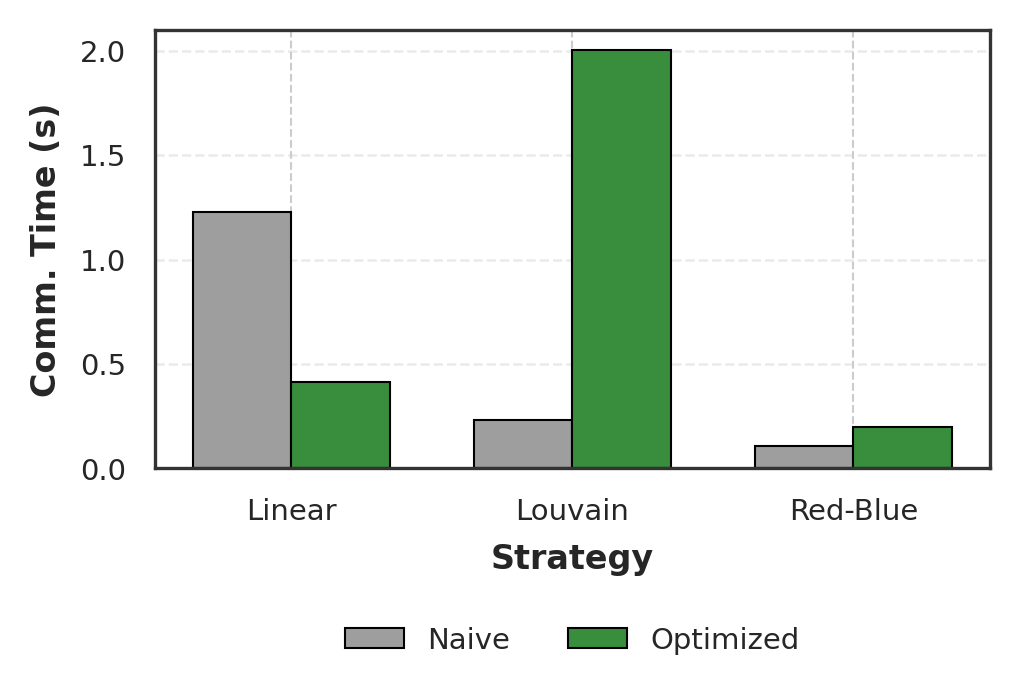

In [26]:
if breakdown_data:
    df_nsys_orig = pd.DataFrame(breakdown_data)
    mpi_df = df_nsys_orig[df_nsys_orig['Implementation'].str.contains('mpi')].copy()
    
    if not mpi_df.empty:
        # Extract variant and strategy
        def parse_impl(name):
            parts = name.split('-')
            variant = parts[0].capitalize()
            # Handle variable length strategies
            if 'red' in parts: strategy = 'Red-Blue'
            elif 'louvain' in parts: strategy = 'Louvain'
            else: strategy = 'Linear'
            return pd.Series([variant, strategy])
        
        mpi_df[['Variant', 'Strategy']] = mpi_df['Implementation'].apply(parse_impl)
        
        # Save to CSV
        mpi_df[['Variant', 'Strategy', 'MPI']].to_csv('paper_figs/fig4_partitioning.csv', index=False)
        
        # Create figure - SINGLE COLUMN
        fig, ax = plt.subplots(figsize=(SINGLE_COL_WIDTH, 2.5 * CHART_HEIGHT_SCALE))
        
        # Grouped bar chart
        strategies = sorted(mpi_df['Strategy'].unique())
        variants = sorted(mpi_df['Variant'].unique())
        
        x = np.arange(len(strategies))
        width = 0.35
        
        variant_colors = {'Naive': '#9E9E9E', 'Optimized': '#388E3C'}
        
        for i, variant in enumerate(variants):
            variant_data = mpi_df[mpi_df['Variant'] == variant]
            # Match strictly
            values = []
            for s in strategies:
                match = variant_data[variant_data['Strategy'] == s]
                if not match.empty:
                    values.append(match['MPI'].values[0])
                else:
                    values.append(0)
            
            offset = (i - 0.5) * width
            ax.bar(x + offset, values, width, label=variant, 
                  color=variant_colors.get(variant, '#333'),
                  edgecolor='black', linewidth=0.5)
        
        ax.set_xlabel('Strategy', fontweight='bold')
        ax.set_ylabel('Comm. Time (s)', fontweight='bold')
        # ax.set_title('Partitioning Impact', pad=8, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels(strategies, rotation=0) # Short labels rarely need rotation
        ax.grid(axis='y', alpha=0.4, linewidth=0.6)
        
        # Legend
        ax.legend(title=None, bbox_to_anchor=(0.5, -0.3), 
                 loc='upper center', frameon=False, ncol=2)
        
        plt.tight_layout()
        plt.savefig('paper_figs/fig4_partitioning.png', bbox_inches='tight', dpi=300)
        plt.show()
    else:
        print("⚠ No MPI data found")
else:
    print("⚠ No data for partitioning analysis")

---
## Figure 5: Kernel Functionality Breakdown

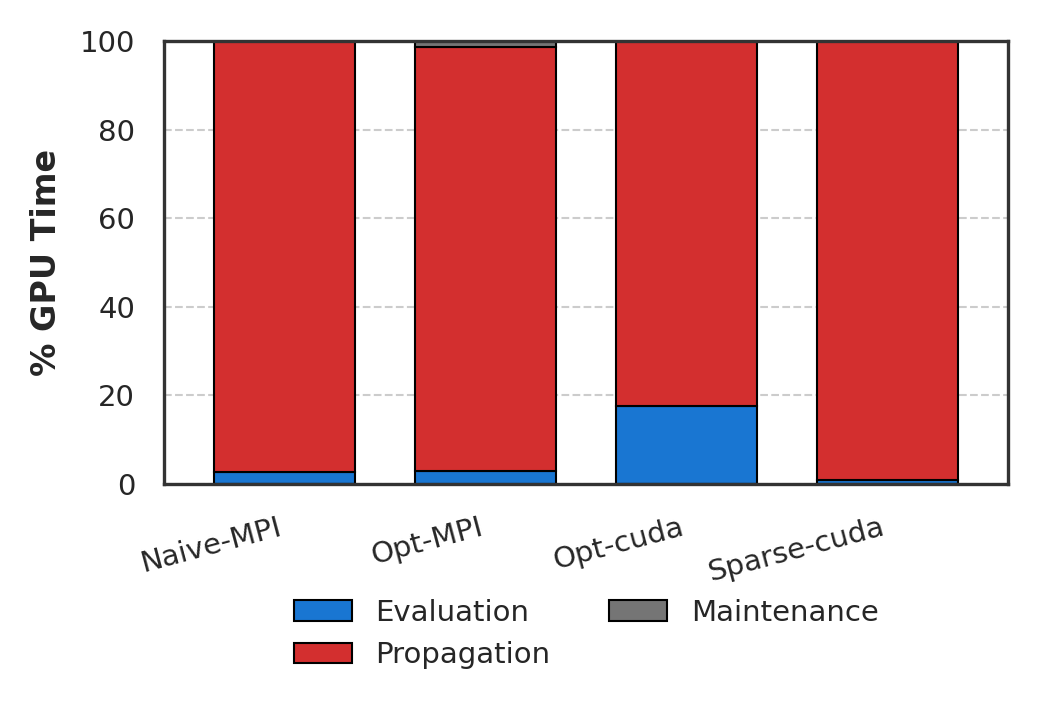

In [27]:
# Kernel to functionality mapping
KERNEL_FUNCTION_MAP = {
    # Old names (for backward compatibility if needed)
    'updateNeuronDynamicsKernel': 'Evaluation',
    'computeSpikingVectorKernel': 'Evaluation',
    
    # New names
    'evaluateNeuronKernel': 'Evaluation',
    'evaluateRulesKernel': 'Evaluation',
    'propagateDelayedSpikesKernel': 'Propagation',

    # Propagation
    'propagateSpikesKernel': 'Propagation',
    'propagateLocalSpikesKernel': 'Propagation',
    'consumeSpikesAndProduceKernel': 'Propagation',
    'updateDelaysAndEmitKernel': 'Propagation',
    'populateExportBufferKernel': 'Propagation',
    'applyImportedSpikesKernel': 'Propagation',
    
    # Maintenance
    'resetNeuronsKernel': 'Maintenance',
    'clearSpikeProductionKernel': 'Maintenance',
    'initializeKernel': 'Maintenance'
}

def parse_ncu_csv(path):
    """
    Parses NCU CSV file, handling units and normalizing to standard units.
    Time -> us
    Data -> MB
    """
    try:
        # Read header and units
        df = pd.read_csv(path, header=0)
        
        if df.empty:
            return df
        
        # Clean columns
        clean_cols = [c.replace('"', '').strip() for c in df.columns]
        
        # Map units
        units_row = df.iloc[0]
        units_map = {clean_c: str(u).strip().lower() for clean_c, u in zip(clean_cols, units_row)}
        
        df.columns = clean_cols
        
        # Drop units row
        df = df.iloc[1:].copy().reset_index(drop=True)
        
        # Clean string columns (remove quotes)
        for col in df.select_dtypes(include=['object']).columns:
             df[col] = df[col].astype(str).str.replace('"', '').str.strip()

        # Convert and normalize
        for col in df.columns:
            unit = units_map.get(col, '')
            
            # Skip non-metrics
            if col in ['ID', 'Process ID', 'Process Name', 'Host Name', 'Kernel Name', 'Context', 'Stream', 'Block Size', 'Grid Size', 'Device', 'CC']:
                continue

            try:
                # Force numeric
                # handle values that might be non-numeric gracefully?
                # pd.to_numeric with coerce turns errors to NaN
                vals = pd.to_numeric(df[col], errors='coerce')
                
                # Check unit
                if unit in ['s', 'second', 'seconds']:
                    vals *= 1e6
                elif unit in ['ms', 'msecond', 'mseconds']:
                    vals *= 1e3
                elif unit in ['ns', 'nsecond', 'nseconds']:
                    vals /= 1e3
                    
                elif unit in ['byte', 'bytes']:
                    vals /= 1e6
                elif unit in ['kbyte', 'kbytes']:
                    vals /= 1e3
                elif unit in ['gbyte', 'gbytes']:
                    vals *= 1e3
                
                df[col] = vals.fillna(0)
                    
            except Exception:
                pass
                
        return df
    except Exception as e:
        print(f"Error parsing NCU CSV {path}: {e}")
        raise e

target_impls = [
    'optimized-cuda',
    'sparse-cuda',
    'naive-cuda-mpi-linear',
    'optimized-cuda-mpi-linear'
]

kernel_data = []

for impl in target_impls:
    metrics_path = NCU_DIR / impl / "snp_profile_metrics.csv"
    if not metrics_path.exists():
        candidates = list((NCU_DIR / impl).glob("*rank0_metrics.csv"))
        if candidates:
            metrics_path = candidates[0]
        else:
            continue
    
    try:
        df = parse_ncu_csv(metrics_path)
        
        def clean_name(name):
            if '(' in name: name = name.split('(')[0]
            if '::' in name: name = name.split('::')[-1]
            return name.strip()
        
        df['CleanName'] = df['Kernel Name'].apply(clean_name)
        df['Functionality'] = df['CleanName'].map(KERNEL_FUNCTION_MAP).fillna('Other')
        df['TimeRaw'] = df['gpu__time_duration.sum']
        
        grouped = df.groupby('Functionality')['TimeRaw'].sum()
        
        for func, time_val in grouped.items():
            # Shorten names
            display_name = impl.replace('cuda-mpi', 'MPI').replace('-linear', '')
            display_name = display_name.replace('optimized', 'Opt').replace('naive', 'Naive').replace('sparse', 'Sparse')
            
            kernel_data.append({
                'Implementation': display_name,
                'Functionality': func,
                'Time': time_val
            })
    
    except Exception as e:
        print(f"⚠ Error processing {impl}: {e}")

if kernel_data:
    df_kernel = pd.DataFrame(kernel_data)
    df_pivot = df_kernel.pivot(index='Implementation', columns='Functionality', values='Time').fillna(0)
    df_pct = df_pivot.div(df_pivot.sum(axis=1), axis=0) * 100
    
    # Order columns
    func_order = ['Evaluation', 'Propagation', 'MPI Communication', 'Maintenance', 'Other']
    cols = [c for c in func_order if c in df_pct.columns]
    df_pct = df_pct[cols]
    
    # Save to CSV
    df_pct.to_csv('paper_figs/fig5_kernel_functionality.csv')
    
    # Create figure - SINGLE COLUMN
    fig, ax = plt.subplots(figsize=(SINGLE_COL_WIDTH, 2.5 * CHART_HEIGHT_SCALE))
    
    df_pct.plot(kind='bar', stacked=True, ax=ax,
               color=[FUNC_COLORS.get(c, '#9E9E9E') for c in df_pct.columns],
               edgecolor='black', linewidth=0.5, width=0.7)
    
    ax.set_xlabel('')
    ax.set_ylabel('% GPU Time', fontweight='bold')
    # ax.set_title('Kernel Functionality', pad=8, fontweight='bold')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=X_LABEL_ROTATION, ha='right')
    ax.set_ylim([0, 100])
    
    # Legend
    ax.legend(title=None, bbox_to_anchor=(0.5, -0.20), 
             loc='upper center', frameon=False, ncol=2)
    
    plt.tight_layout()
    plt.savefig('paper_figs/fig5_kernel_functionality.png', bbox_inches='tight', dpi=300)
    plt.show()
else:
    print("⚠ No kernel data available")

---
## Figure 6: Memory Hierarchy Utilization

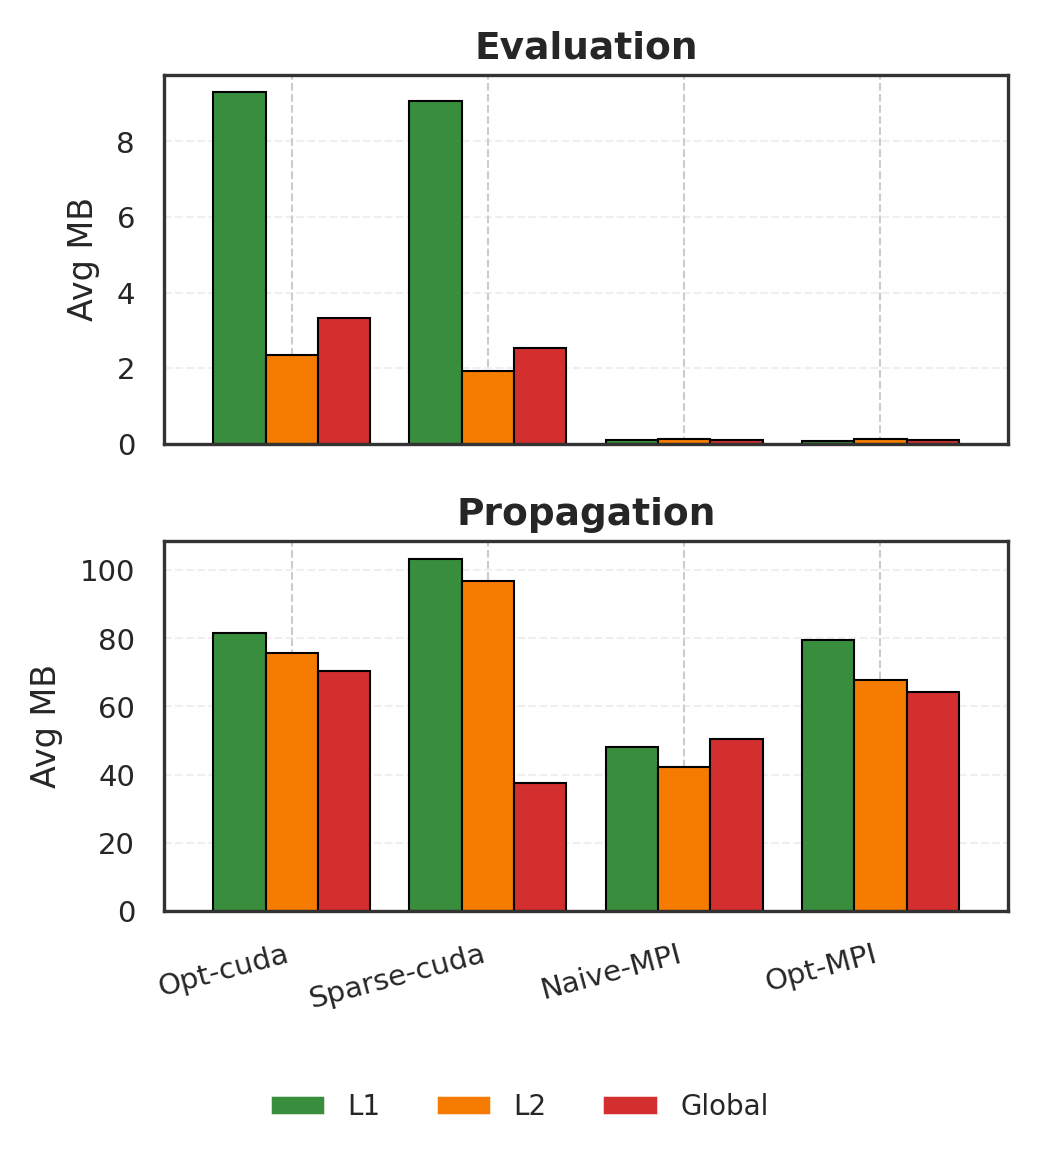

In [31]:
mem_data = []

for impl in target_impls:
    metrics_path = NCU_DIR / impl / "snp_profile_metrics.csv"
    if not metrics_path.exists():
        candidates = list((NCU_DIR / impl).glob("*rank0_metrics.csv"))
        if candidates:
            metrics_path = candidates[0]
        else:
            continue
    
    try:
        df = parse_ncu_csv(metrics_path)
        
        def clean_name(name):
            if '(' in name: name = name.split('(')[0]
            if '::' in name: name = name.split('::')[-1]
            return name.strip()
        
        df['CleanName'] = df['Kernel Name'].apply(clean_name)
        df['Functionality'] = df['CleanName'].map(KERNEL_FUNCTION_MAP).fillna('Other')
        
        # Memory columns
        mem_cols = [
            'dram__bytes_read.sum', 'dram__bytes_write.sum',
            'l1tex__t_bytes_lookup_hit.sum', 'l1tex__t_bytes_lookup_miss.sum',
            'lts__t_sectors_lookup_hit.sum', 'lts__t_sectors_lookup_miss.sum'
        ]
        
        for col in mem_cols:
            if col not in df.columns:
                df[col] = 0
            # Already numeric
        
        # USE MEAN INSTEAD OF SUM
        group = df.groupby('Functionality')[mem_cols].mean()
        
        for func, row in group.iterrows():
            if func not in ['Evaluation', 'Propagation']:
                continue
            
            dram_mb = row['dram__bytes_read.sum'] + row['dram__bytes_write.sum']
            l1_mb = row['l1tex__t_bytes_lookup_hit.sum'] + row['l1tex__t_bytes_lookup_miss.sum']
            l2_sectors = row['lts__t_sectors_lookup_hit.sum'] + row['lts__t_sectors_lookup_miss.sum']
            l2_mb = l2_sectors * 32.0 / 1e6
            
            display_name = impl.replace('cuda-mpi', 'MPI').replace('-linear', '')
            display_name = display_name.replace('optimized', 'Opt').replace('naive', 'Naive').replace('sparse', 'Sparse')
            
            mem_data.append({'Implementation': display_name, 'Functionality': func, 
                           'Memory': 'L1 Cache', 'TrafficMB': l1_mb})
            mem_data.append({'Implementation': display_name, 'Functionality': func, 
                           'Memory': 'L2 Cache', 'TrafficMB': l2_mb})
            mem_data.append({'Implementation': display_name, 'Functionality': func, 
                           'Memory': 'Global Memory', 'TrafficMB': dram_mb})
    
    except Exception as e:
        print(f"⚠ Error processing {impl}: {e}")

if mem_data:
    df_mem = pd.DataFrame(mem_data)
    
    # Save to CSV
    df_mem.to_csv('paper_figs/fig6_memory_hierarchy.csv', index=False)
    
    # Get unique implementations preserving order
    unique_impls = []
    for x in df_mem['Implementation']:
        if x not in unique_impls:
            unique_impls.append(x)
            
    mem_types = ['L1 Cache', 'L2 Cache', 'Global Memory']
    functionalities = ['Evaluation', 'Propagation']
    
    # Create figure - TWO ROWS (Evaluation, Propagation)
    fig, axes = plt.subplots(2, 1, figsize=(SINGLE_COL_WIDTH, 4.0 * CHART_HEIGHT_SCALE), sharex=True)
    
    for idx, func in enumerate(functionalities):
        ax = axes[idx]
        
        subset = df_mem[df_mem['Functionality'] == func]
        if not subset.empty:
            pivot = subset.pivot(index='Implementation', columns='Memory', values='TrafficMB').fillna(0)
            
            # Reorder rows
            valid_impls = [i for i in unique_impls if i in pivot.index]
            pivot = pivot.reindex(valid_impls)
            
            # Reorder columns
            pivot = pivot[mem_types]
            
            pivot.plot(kind='bar', ax=ax, 
                      color=[MEM_COLORS[c] for c in pivot.columns],
                      edgecolor='black', linewidth=0.5, width=0.8, legend=False)
            
            ax.set_title(func, fontweight='bold', fontsize=9, pad=4)
            ax.set_ylabel('Avg MB', fontsize=8)
            ax.grid(axis='y', alpha=0.3)
        else:
             ax.text(0.5, 0.5, 'No Data', ha='center', va='center')
    
    axes[-1].set_xlabel('')
    axes[-1].set_xticklabels(axes[-1].get_xticklabels(), rotation=X_LABEL_ROTATION, ha='right')
    
    # Consolidated legend at bottom
    handles = [plt.Rectangle((0,0),1,1, facecolor=MEM_COLORS[m], edgecolor=None) 
              for m in mem_types]
    
    fig.legend(handles, ['L1', 'L2', 'Global'], 
              loc='lower center', bbox_to_anchor=(0.5, 0.0), 
              ncol=3, frameon=False, fontsize='small')
    
    # fig.suptitle('Average Memory Traffic', fontweight='bold', y=0.98, fontsize=10)
    plt.tight_layout(rect=[0, 0.08, 1, 0.96])
    plt.savefig('paper_figs/fig6_memory_hierarchy.png', bbox_inches='tight', dpi=300)
    plt.show()
else:
    print("⚠ No memory data available")

---
## Figure 7: Warp Stall Analysis

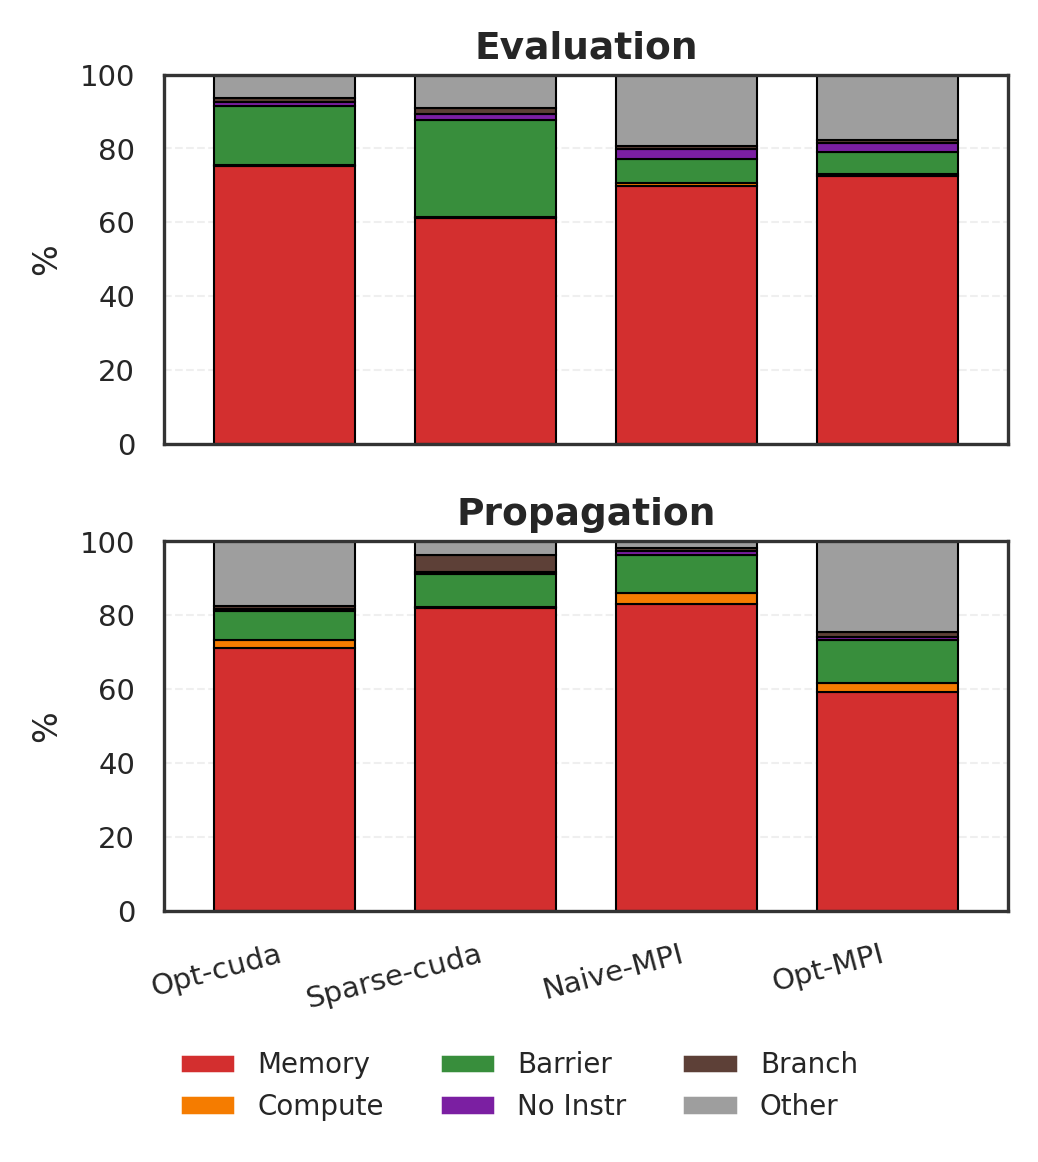

In [32]:
# Key stall metrics
STALL_METRICS = {
    'smsp__warp_issue_stalled_long_scoreboard_per_warp_active.pct': 'Memory',
    'smsp__warp_issue_stalled_short_scoreboard_per_warp_active.pct': 'Compute',
    'smsp__warp_issue_stalled_wait_per_warp_active.pct': 'Barrier',
    'smsp__warp_issue_stalled_no_instruction_per_warp_active.pct': 'No Instr',
    'smsp__warp_issue_stalled_branch_resolving_per_warp_active.pct': 'Branch'
}

stall_data = []
display_order = []

for impl in target_impls:
    metrics_path = NCU_DIR / impl / "snp_profile_metrics.csv"
    if not metrics_path.exists():
        candidates = list((NCU_DIR / impl).glob("*rank0_metrics.csv"))
        if candidates:
            metrics_path = candidates[0]
        else:
            continue
    
    try:
        df = parse_ncu_csv(metrics_path)
        
        def clean_name(name):
            if '(' in name: name = name.split('(')[0]
            if '::' in name: name = name.split('::')[-1]
            return name.strip()
        
        df['CleanName'] = df['Kernel Name'].apply(clean_name)
        df['Functionality'] = df['CleanName'].map(KERNEL_FUNCTION_MAP).fillna('Other')
        
        if 'gpu__time_duration.sum' not in df.columns:
            continue
        
        df['Duration'] = df['gpu__time_duration.sum']
        
        # Calculate weighted contributions
        for col, label in STALL_METRICS.items():
            if col in df.columns:
                df[f'{label}_weighted'] = df[col] * df['Duration']
        
        # Group by Functionality
        # We process 'Evaluation' and 'Propagation' separately
        grouped = df.groupby('Functionality')
        
        display_name = impl.replace('cuda-mpi', 'MPI').replace('-linear', '')
        display_name = display_name.replace('optimized', 'Opt').replace('naive', 'Naive').replace('sparse', 'Sparse')
        
        if display_name not in display_order:
            display_order.append(display_name)
            
        for func in ['Evaluation', 'Propagation']:
            if func in grouped.groups:
                func_df = grouped.get_group(func)
                total_dur = func_df['Duration'].sum()
                
                if total_dur > 0:
                    total_stall = 0.0
                    
                    for label in STALL_METRICS.values():
                        col_name = f'{label}_weighted'
                        if col_name in func_df.columns:
                            weighted = func_df[col_name].sum()
                            avg_pct = weighted / total_dur
                            total_stall += avg_pct
                            
                            stall_data.append({
                                'Implementation': display_name,
                                'Functionality': func,
                                'Stall': label,
                                'Percentage': avg_pct
                            })
                    
                    stall_data.append({
                        'Implementation': display_name,
                        'Functionality': func,
                        'Stall': 'Other',
                        'Percentage': max(0, 100.0 - total_stall)
                    })
    
    except Exception as e:
        print(f"⚠ Error processing {impl}: {e}")

if stall_data:
    df_stall = pd.DataFrame(stall_data)
    
    # Save to CSV
    df_stall.to_csv('paper_figs/fig7_warp_stalls_separated.csv', index=False)
    
    # Stall colors (semantic)
    stall_colors = {
        'Memory': '#D32F2F',      # Red (critical)
        'Compute': '#F57C00',     # Orange
        'Barrier': '#388E3C',     # Green
        'No Instr': '#7B1FA2',   # Purple
        'Branch': '#5D4037',      # Brown
        'Other': '#9E9E9E'        # Grey
    }
    
    # Create figure - TWO ROWS (Evaluation, Propagation)
    fig, axes = plt.subplots(2, 1, figsize=(SINGLE_COL_WIDTH, 4.0 * CHART_HEIGHT_SCALE), sharex=True)
    
    functionalities = ['Evaluation', 'Propagation']
    
    # Prepare pivot data for both to ensure consistent columns/colors
    pivot_all = df_stall.pivot_table(index=['Functionality', 'Implementation'], columns='Stall', values='Percentage').fillna(0)
    cols = [c for c in stall_colors.keys() if c in pivot_all.columns]
    
    for idx, func in enumerate(functionalities):
        ax = axes[idx]
        
        # Check if we have data for this functionality
        if func in df_stall['Functionality'].values:
            # Extract data for this func
            subset = df_stall[df_stall['Functionality'] == func]
            pivot = subset.pivot(index='Implementation', columns='Stall', values='Percentage').fillna(0)
            
            # Reorder rows
            pivot = pivot.reindex([d for d in display_order if d in pivot.index])
            # Reorder cols
            pivot = pivot[cols]
            
            pivot.plot(kind='bar', stacked=True, ax=ax,
                      color=[stall_colors.get(c, '#333') for c in pivot.columns],
                      edgecolor='black', linewidth=0.5, width=0.7, legend=False)
            
            ax.set_title(func, fontweight='bold', fontsize=9, pad=4)
            ax.set_ylabel('%', fontsize=8)
            ax.set_ylim([0, 100])
            ax.grid(axis='y', alpha=0.3)
        else:
            ax.text(0.5, 0.5, 'No Data', ha='center', va='center')
    
    axes[-1].set_xlabel('')
    axes[-1].set_xticklabels(axes[-1].get_xticklabels(), rotation=X_LABEL_ROTATION, ha='right')
    
    # Consolidated legend
    handles = [plt.Rectangle((0,0),1,1, facecolor=stall_colors[s], edgecolor=None) 
              for s in cols]
    
    fig.legend(handles, cols, 
              loc='lower center', bbox_to_anchor=(0.5, 0.0), 
              ncol=3, frameon=False, fontsize='small')
    
    # fig.suptitle('Warp Stall Breakdown', fontweight='bold', y=0.98, fontsize=10)
    plt.tight_layout(rect=[0, 0.08, 1, 0.96])
    plt.savefig('paper_figs/fig7_warp_stalls.png', bbox_inches='tight', dpi=300)
    plt.show()
else:
    print("⚠ No stall data available")

---
## Figure 8: Big Data Benchmark Results
This benchmark analyzes the maximum achievable model size for different implementations by progressively increasing the neuron count until memory limits or timeouts are reached. The synthetic model uses high intra-node and low inter-node connectivity.

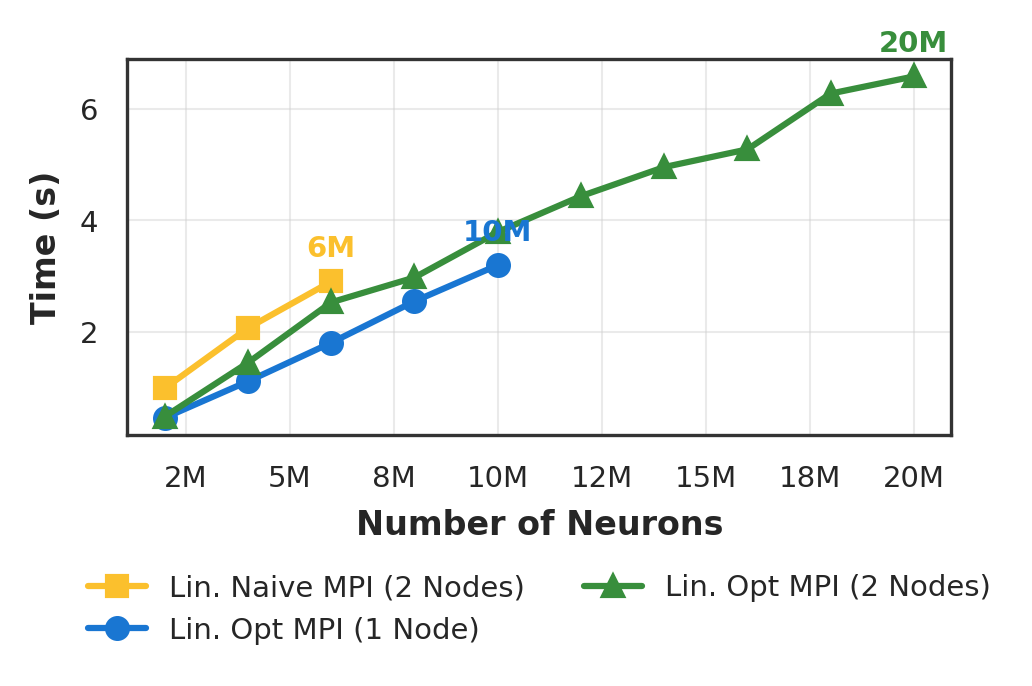

In [30]:
# ==================== FIGURE 8: BIG DATA BENCHMARK ====================

from matplotlib.ticker import FuncFormatter

bigdata_files = [
    {
        'path': Path('bigdata/results/naive-mpi-2-nodes.csv'),
        'label': 'Lin. Naive MPI (2 Nodes)',
        'color': IMPL_COLORS['naive-cuda-mpi:linear'], 
        'marker': 's'
    },
    {
        'path': Path('bigdata/results/optimized-mpi-1-node.csv'),
        'label': 'Lin. Opt MPI (1 Node)',
        'color': IMPL_COLORS['optimized-cuda'],
        'marker': 'o'
    },
    {
        'path': Path('bigdata/results/optimized-mpi-2-nodes.csv'),
        'label': 'Lin. Opt MPI (2 Nodes)',
        'color': IMPL_COLORS['optimized-cuda-mpi:linear'],
        'marker': '^'
    }
]

bigdata_dfs = []

for item in bigdata_files:
    if item['path'].exists():
        try:
            df_bd = pd.read_csv(item['path'])
            # Normalize column names
            df_bd.columns = [c.lower().strip() for c in df_bd.columns]
            
            # Ensure 'neurons' and 'total_time_s' exist
            if 'neurons' in df_bd.columns and 'total_time_s' in df_bd.columns:
                df_bd['Implementation'] = item['label']
                df_bd['Color'] = item['color']
                df_bd['Marker'] = item['marker']
                bigdata_dfs.append(df_bd)
        except Exception as e:
            print(f"Error loading {item['path']}: {e}")
    else:
        print(f"Warning: {item['path']} does not exist")

if bigdata_dfs:
    df_bigdata = pd.concat(bigdata_dfs, ignore_index=True)
    
    # Save processed data
    df_bigdata.to_csv('paper_figs/fig8_bigdata.csv', index=False)
    
    # Create Figure - SINGLE COLUMN
    fig, ax = plt.subplots(figsize=(SINGLE_COL_WIDTH, 2.5 * CHART_HEIGHT_SCALE))
    
    # Custom formatter for millions
    def millions(x, pos):
        return '%1.0fM' % (x * 1e-6)
    
    for label in df_bigdata['Implementation'].unique():
        subset = df_bigdata[df_bigdata['Implementation'] == label]
        # Find metadata safely
        meta = next((item for item in bigdata_files if item['label'] == label), None)
        if not meta: continue
        
        # Sort by neurons 
        subset = subset.sort_values('neurons')
        
        ax.plot(subset['neurons'], subset['total_time_s'], 
               label=label, color=meta['color'], marker=meta['marker'],
               linewidth=1.5, markersize=5)
        
        # Annotate max size achieved
        max_pt = subset.iloc[-1]
        ax.annotate(f"{max_pt['neurons']/1e6:.0f}M", 
                   (max_pt['neurons'], max_pt['total_time_s']),
                   xytext=(0, 6), textcoords='offset points', ha='center',
                   fontsize=7, fontweight='bold', color=meta['color'])

    ax.set_xlabel('Number of Neurons', fontweight='bold')
    ax.set_ylabel('Time (s)', fontweight='bold')
    # ax.set_title('Max Model Size & Perf.', pad=8, fontweight='bold')
    
    # Formatting
    ax.set_xscale('linear')
    ax.xaxis.set_major_formatter(FuncFormatter(millions))
    
    ax.grid(True, which='major', alpha=0.4, linestyle='-')
    
    # Legend - Stack vertically for single column
    ax.legend(bbox_to_anchor=(0.5, -0.3), loc='upper center', frameon=False, ncol=2)
    
    plt.tight_layout()
    plt.savefig('paper_figs/fig8_bigdata.png', bbox_inches='tight', dpi=300)
    plt.show()

else:
    print("No big data results found.")

---
## Summary

All visualizations have been generated with improved styling:

✓ **Enhanced Readability**
- Larger, clearer fonts
- Better color contrasts
- Consistent styling across all figures

✓ **Professional Appearance**
- Colorblind-friendly palettes
- Clean grid lines and borders
- Proper spacing and alignment

✓ **Improved Legends**
- All legends positioned below charts
- Consolidated legends for multi-subplot figures
- Clear, readable labels

**Figures Generated:**
1. Scaling Performance (Speedup Analysis)
2. Distribution Stability Analysis
3. Execution Time Breakdown
4. Partitioning Strategy Impact
5. Kernel Functionality Breakdown
6. Memory Hierarchy Utilization
7. Warp Stall Analysis
8. Big Data Benchmark (Max Model Size)